In [ ]:
#Hey guys Good Evng!
#Lets wait till 8:09PM and then we will start with the session

In [ ]:
# Agenda -- PCA handson

In [ ]:
# principal component analysis--unsupervised
#Dimensionality Reduction
#Create new features (called principal components ) that capture the most important patterns in your data.

In [ ]:
#What are steps for PCA

#Standardize the data --->This puts all the features on the same scale.
#Compute the covariance matrix --->To check Relationship btwn features
#Calculating the eigen values and eigen vectors  | vector = direction and value = importance
#sort the data in descending order to pick the most imp features
#transform the data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [ ]:
digits=load_digits()

In [ ]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [ ]:
df=pd.DataFrame(digits.data,columns=digits.feature_names)

In [ ]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,16.0,14.0,12.0,16.0,3.0,0.0,0.0,4.0,16.0,6.0,3.0,16.0,4.0,0.0,0.0,0.0,12.0,16.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,4.0,4.0,16.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,5.0,0.0,0.0,0.0,5.0,7.0,7.0,16.0,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,16.0,15.0,12.0,16.0,1.0,0.0,0.0,3.0,16.0,7.0,0.0,13.0,6.0,0.0,0.0,4.0,16.0,0.0,0.0,10.0,8.0,0.0,0.0,8.0,16.0,0.0,0.0,14.0,6.0,0.0,0.0,5.0,16.0,7.0,9.0,16.0,5.0,0.0,0.0,1.0,15.0,16.0,16.0,16.0,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,13.0,16.0,8.0,2.0,1.0,0.0,0.0,0.0,16.0,15.0,10.0,16.0,5.0,0.0,0.0,0.0,8.0,16.0,16.0,7.0,0.0,0.0,0.0,0.0,9.0,16.0,16.0,4.0,0.0,0.0,0.0,0.0,16.0,14.0,16.0,15.0,0.0,0.0,0.0,0.0,15.0,15.0,15.0,16.0,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,14.0,16.0,16.0,15.0,1.0,0.0,0.0,4.0,16.0,7.0,3.0,16.0,7.0,0.0,0.0,5.0,16.0,10.0,7.0,16.0,4.0,0.0,0.0,0.0,5.0,14.0,14.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,2.0,0.0,0.0,0.0,4.0,7.0,7.0,16.0,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [ ]:
x=digits.data
y=digits.target

In [ ]:
z=x[0].reshape(8,8)
z

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

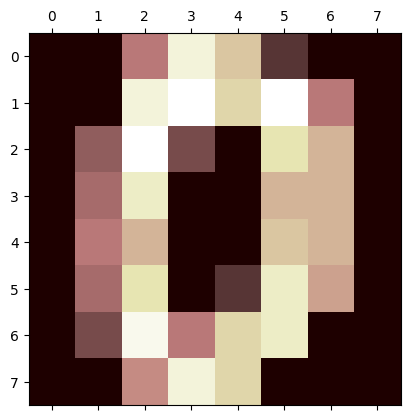

In [ ]:
plt.pink()
plt.matshow(z)
plt.show()

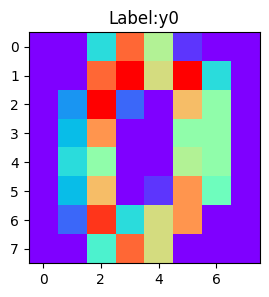

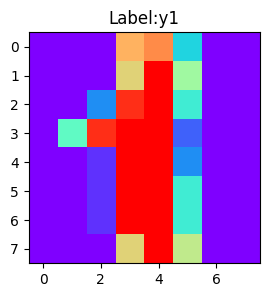

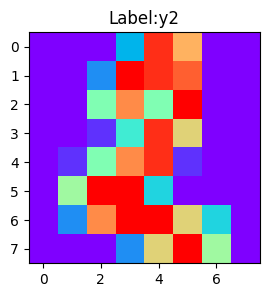

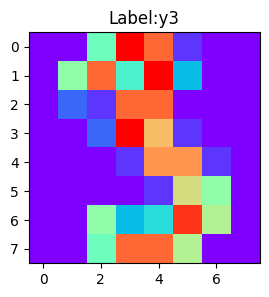

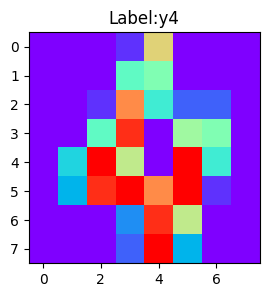

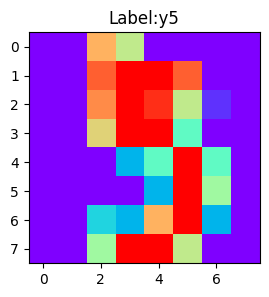

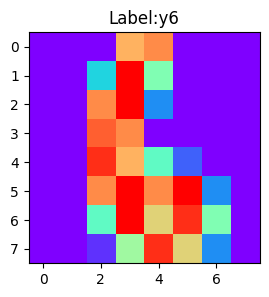

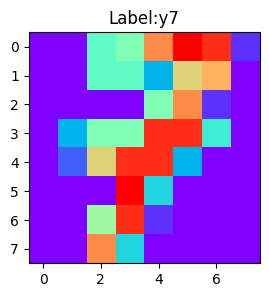

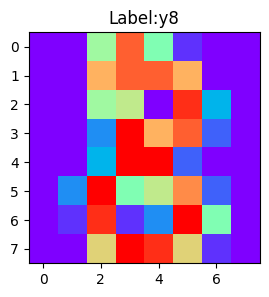

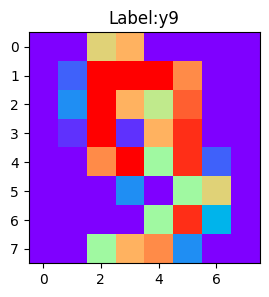

In [ ]:
for i in range(10):
  plt.figure(figsize=(3,3))
  image=x[i].reshape(8,8)
  plt.imshow(image,cmap='rainbow')
  plt.title(f"Label:y{i}")
  plt.show()

In [ ]:
#Implement PCA


from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [ ]:
x_scaled=scalar.fit_transform(x)

In [ ]:
x_scaled.T

# here by default the covairiance takes default as features so we do transpose otherwise it will find the relationship between images to images 

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.33501649, -0.33501649, -0.33501649, ..., -0.33501649,
        -0.33501649, -0.33501649],
       [-0.04308102, -1.09493684, -1.09493684, ..., -0.88456568,
        -0.67419451,  1.00877481],
       ...,
       [-1.14664746,  0.54856067,  1.56568555, ..., -0.12952258,
         0.8876023 ,  0.8876023 ],
       [-0.5056698 , -0.5056698 ,  1.6951369 , ..., -0.5056698 ,
        -0.5056698 , -0.26113572],
       [-0.19600752, -0.19600752, -0.19600752, ..., -0.19600752,
        -0.19600752, -0.19600752]])

In [ ]:
print(x_scaled.shape)
print(x_scaled.T.shape)

(1797, 64)
(64, 1797)


In [ ]:
cov_mat =np.cov(x_scaled.T)
pd.DataFrame(cov_mat)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,1.000557,0.556928,0.207929,-0.018771,0.060810,0.048415,-0.038948,0.032338,0.556682,0.224647,-0.109117,0.027923,-0.064019,-0.029990,-0.043722,-0.005112,0.213705,-0.113644,-0.105941,0.096307,-0.170165,-0.131403,-0.038288,-0.011189,-0.085959,-0.146465,0.073021,0.041106,-0.206433,-0.150838,-0.015832,0.0,-0.168389,-0.178587,0.044164,-0.059892,-0.235907,-0.173342,0.0,-0.020563,-0.124336,-0.143079,0.024256,-0.054747,-0.163363,-0.086514,-0.025750,-0.011877,0.225901,0.115345,0.020393,0.031472,-0.009585,0.030970,-0.045368,-0.007910,0.856086,0.556036,0.147728,-0.102406,-0.029887,0.026562,-0.043913
2,0.0,0.556928,1.000557,0.560492,-0.084282,0.043593,0.002842,-0.062313,0.022324,0.582583,0.631819,-0.286185,0.028814,0.063283,-0.089271,-0.100582,-0.016952,0.279019,-0.084298,-0.310899,0.208843,-0.086678,-0.217778,-0.118991,-0.036569,-0.153185,-0.310691,0.108438,0.199873,-0.193867,-0.192188,-0.051745,0.0,-0.344253,-0.396652,-0.055746,-0.120454,-0.279945,-0.183423,0.0,-0.067205,-0.268878,-0.342134,-0.157557,-0.203360,-0.190082,-0.069254,-0.064818,-0.038819,0.205911,0.262322,-0.042555,-0.051559,0.082911,0.050877,-0.003806,-0.025851,0.515563,0.938145,0.500118,-0.134829,-0.041206,0.072639,0.082569
3,0.0,0.207929,0.560492,1.000557,0.023952,-0.171473,-0.115796,-0.040162,0.035683,0.328527,0.596812,-0.002442,-0.068664,0.023176,-0.178903,-0.113894,0.022749,0.187916,0.040538,-0.360640,0.067980,-0.018325,-0.225018,-0.149841,-0.002641,-0.109321,-0.256436,-0.057140,0.090228,-0.183359,-0.141853,-0.067710,0.0,-0.227582,-0.224502,0.017616,-0.078007,-0.226619,-0.037244,0.0,-0.099680,-0.257979,-0.102260,-0.025316,-0.243965,-0.214864,0.089753,0.046945,-0.062833,0.015456,0.299929,0.279576,-0.180632,0.022409,0.139475,0.075376,-0.049112,0.175902,0.560638,0.768373,-0.065993,-0.054966,0.053467,0.082016
4,0.0,-0.018771,-0.084282,0.023952,1.000557,0.508014,0.127835,0.010070,0.042089,0.051686,0.014006,-0.135790,0.160358,0.390252,0.133699,0.014513,0.009916,0.036632,-0.124521,-0.155587,-0.029041,0.182773,0.078376,0.023900,0.008976,0.027058,-0.063230,0.036251,0.089704,0.122616,0.078100,0.012701,0.0,-0.028088,-0.015673,0.026608,0.069954,0.089136,0.051437,0.0,0.023655,-0.018374,-0.095207,-0.037596,0.051742,0.074616,-0.090171,-0.039552,0.024162,-0.020588,-0.165693,-0.043673,0.030331,-0.120628,-0.265116,-0.212339,0.017362,-0.047250,-0.020187,-0.008872,-0.082171,-0.215929,-0.250838,-0.215469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.0,0.147728,0.500118,0.768373,-0.008872,-0.068076,-0.045871,0.001013,0.043398,0.305361,0.634445,0.048290,-0.160577,0.070561,-0.066914,-0.055108,0.021551,0.227565,0.140454,-0.340207,-0.063278,-0.015597,-0.130327,-0.110918,-0.000680,-0.023925,-0.189694,-0.053607,0.036487,-0.190487,-0.157863,-0.030678,0.0,-0.212819,-0.285548,-0.077900,-0.116675,-0.195208,-0.041779,0.0,-0.078437,-0.232945,-0.163889,-0.166237,-0.198045,-0.129254,0.081948,0.006893,-0.040630,0.036485,0.229197,0.153751,-0.061718,0.065216,0.094770,0.050060,-0.038269,0.113035,0.481979,1.000557,0.058423,-0.095009,0.006853,0.099727
60,0.0,-

In [ ]:
eig_val,eig_vec=np.linalg.eig(cov_mat)

In [ ]:
pd.DataFrame(eig_vec)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0
1,0.182234,-0.047027,0.023588,-0.178153,-0.029978,0.231723,-0.108310,0.125524,0.213820,0.059834,-0.049941,0.204254,0.133801,-0.041487,0.130818,-0.082027,0.171821,0.065722,-0.137138,0.098283,0.006642,-0.029304,0.114117,-0.196266,0.101727,0.120121,-0.037933,0.095185,0.097288,0.046406,0.069916,0.050244,0.060175,0.002171,0.102210,0.087139,0.024623,-0.026354,-0.022276,0.063996,0.022867,-0.085241,-0.015791,-0.016542,-0.023658,-0.013188,0.064751,0.562510,-0.134134,-0.203051,0.159522,-0.023657,0.136114,-0.168755,0.039356,-0.036629,0.082404,0.052290,0.197267,0.024853,0.052605,0.0,0.0,0.0
2,0.285868,-0.059565,-0.056799,-0.156129,-0.014666,0.119875,-0.004755,0.006178,0.120140,0.007681,-0.147540,-0.044570,0.031574,0.038609,-0.100309,-0.022455,-0.018188,-0.016911,-0.020551,-0.025342,-0.117158,0.005074,-0.134998,0.011292,0.011514,-0.068861,0.158987,-0.058283,-0.269276,-0.025233,-0.010893,-0.047724,-0.069043,-0.008342,-0.095020,-0.024501,-0.025384,0.686446,0.141543,-0.187823,-0.139281,-0.033334,0.052102,0.044499,0.101491,0.098357,-0.024959,0.036255,0.067830,-0.076872,0.002794,-0.021571,0.052227,-0.008411,-0.080164,0.176636,0.091203,-0.001822,-0.129372,-0.069592,-0.090823,0.0,0.0,0.0
3,0.220370,0.020804,-0.040464,-0.167800,0.043716,-0.100392,0.233717,-0.033408,-0.101895,-0.021639,-0.155505,-0.188568,0.064244,0.183513,-0.044552,-0.074244,0.024539,-0.010330,0.024455,-0.001167,-0.039253,0.106731,0.031537,-0.134422,0.114013,0.030726,-0.129626,0.097933,-0.086204,0.171524,-0.024466,0.040695,0.122914,-0.030803,-0.100501,-0.099773,-0.121309,-0.018188,-0.140677,0.192645,-0.015434,0.099778,0.074707,0.120277,-0.060721,0.067932,0.080744,0.057566,-0.069727,0.227598,0.161706,-0.138867,-0.312667,-0.251349,0.125306,-0.224852,-0.089657,0.040788,-0.148353,0.052446,-0.323498,0.0,0.0,0.0
4,-0.025170,-0.155903,-0.067065,0.000009,-0.139993,-0.093471,-0.039540,0.046161,-0.093102,0.005066,0.163472,-0.059178,0.073513,0.158989,0.299957,-0.291598,-0.043592,0.329826,0.215418,-0.183349,-0.089078,0.313472,0.256792,-0.136360,-0.042908,-0.127998,-0.010016,-0.076130,-0.050861,0.177831,0.069299,-0.090964,0.089213,-0.010605,0.164332,-0.037811,-0.040325,0.056287,0.135681,0.004931,0.013144,0.208727,0.039015,0.165961,0.035744,-0.045223,-0.070202,-0.000663,0.033402,-0.099464,-0.109118,0.204155,0.139449,0.022663,0.049967,-0.024456,0.039529,0.012110,-0.072823,-0.057241,0.048470,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.194449,0.009905,-0.083464,-0.171490,0.100375,-0.086503,0.135319,-0.098852,-0.115978,-0.105825,-0.121201,-0.236655,0.042706,0.262494,-0.081153,-0.074291,0.013292,-0.040549,0.045488,0.015010,0.106982,0.089599,0.120630,-0.040321,0.237434,0.131049,-0.033045,0.016252,0.057169,0.048019,-0.084464,0.034424,0.038414,-0.057748,-0.177854,-0.051180,0.050351,0.042972,-0.165062,-0.006137,0.110623,-0.105299,-0.032100,-0.252308,-0.045709,-0.005867,-0.137432,-0.060826,-0.019611,-0.181839,-0.108749,0.135819,0.214148,0.248310,-0.067003,0.101720,-0.245611,-0.069682,0.336075,0.080163,0.138750,0.0,0.0,0.0
60,0.017774,0.251934,-

In [ ]:
pd.DataFrame(eig_val)

,0
0,7.344776
1,5.835491
2,5.153961
3,3.966236
4,2.966345
...,...
59,0.200091
60,0.189835
61,0.000000
62,0.000000


In [ ]:
total=sum(eig_val)


In [ ]:
exp_var=[]
for i in sorted(eig_val,reverse=True):
  exp_var.append((i/total)*100)

exp_var

[np.float64(12.033916097734904),
 np.float64(9.561054403097883),
 np.float64(8.444414892624566),
 np.float64(6.498407907524167),
 np.float64(4.860154875966403),
 np.float64(4.214119869271944),
 np.float64(3.9420828035674003),
 np.float64(3.3893809246383264),
 np.float64(2.998221011625232),
 np.float64(2.9320025512522068),
 np.float64(2.781805463550326),
 np.float64(2.5770550925819995),
 np.float64(2.2753033157642486),
 np.float64(2.227179739514353),
 np.float64(2.1652294318492435),
 np.float64(1.9141666064421259),
 np.float64(1.7755470851681938),
 np.float64(1.6380692742844212),
 np.float64(1.5964601688623428),
 np.float64(1.4891911870878194),
 np.float64(1.3479695658179378),
 np.float64(1.2719313702347599),
 np.float64(1.1658373505919493),
 np.float64(1.0576465985363224),
 np.float64(0.9753159471981139),
 np.float64(0.9445589897319981),
 np.float64(0.8630138269707229),
 np.float64(0.8366428536685183),
 np.float64(0.7976932484112456),
 np.float64(0.7464713709260611),
 np.float64(0.7255

In [ ]:
#cumulative explained variance
cum_exp_var= np.cumsum(exp_var)
pd.DataFrame(cum_exp_var)


# here row indicates pixel number
#  column indicates direction number

# pixel is contributing 12.03 this much amount on direction 1

,0
0,12.033916
1,21.594971
2,30.039385
3,36.537793
4,41.397948
...,...
59,99.917465
60,100.000000
61,100.000000
62,100.000000


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca =PCA(0.95)
x_pca=pca.fit_transform(x)

In [ ]:
x_pca.shape

(1797, 29)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_pca,y,test_size=0.2,random_state=42)


In [ ]:
model=LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
ypred=model.predict(x_test)

In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(ypred,y_test)

0.9611111111111111

In [ ]:
confusion_matrix(y_test,ypred)

array([[33,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 27,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, 31,  1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 33,  0,  1,  0,  0,  0,  0],
       [ 0,  1,  0,  0, 45,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0, 44,  1,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  1, 34,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0, 33,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0, 29,  0],
       [ 0,  1,  0,  1,  0,  0,  0,  0,  1, 37]])